In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image
from umap import UMAP
import re
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [238]:
# # Load dataset
# df = pd.read_excel("3 year 21-22-23 SAC Agg.xlsx")

# df.head()
# df.columns
# df.info()

In [239]:
# Load dataset
intakes = pd.read_csv("Austin_Animal_Center_Intakes__10_01_2013_to_05_05_2025_.csv")

intakes.head()
intakes.columns
intakes.info()

<class 'pandas.DataFrame'>
RangeIndex: 173812 entries, 0 to 173811
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Animal ID         173812 non-null  str  
 1   Name              123821 non-null  str  
 2   DateTime          173812 non-null  str  
 3   MonthYear         173812 non-null  str  
 4   Found Location    173812 non-null  str  
 5   Intake Type       173812 non-null  str  
 6   Intake Condition  173812 non-null  str  
 7   Animal Type       173812 non-null  str  
 8   Sex upon Intake   173811 non-null  str  
 9   Age upon Intake   173812 non-null  str  
 10  Breed             173812 non-null  str  
 11  Color             173812 non-null  str  
dtypes: str(12)
memory usage: 15.9 MB


In [240]:
# Load dataset
outcomes = pd.read_csv("Austin_Animal_Center_Outcomes__10_01_2013_to_05_05_2025_.csv")

# outcomes.head()
# outcomes.columns
# outcomes.info()

df = intakes.merge(outcomes, on="Animal ID", suffixes=("_intake", "_outcome"))

In [241]:
def convert_age(age_str):
    if pd.isna(age_str):
        return None
    num, unit = age_str.split()
    num = int(num)
    
    if "day" in unit:
        return num
    elif "week" in unit:
        return num * 7
    elif "month" in unit:
        return num * 30
    elif "year" in unit:
        return num * 365

df["Age_days"] = df["Age upon Intake"].apply(convert_age)

In [242]:
# Sex
df["Sex"] = df["Sex upon Intake"].str.split().str[0]  # Male/Female/Unknown

# Breed (basic grouping)
df["Breed_simple"] = df["Breed_intake"].apply(lambda x: x.split("/")[0])

# Color (take primary color)
df["Color_simple"] = df["Color_intake"].apply(lambda x: x.split("/")[0])

In [243]:
features = df[["Age_days", "Animal Type_intake", "Sex", "Breed_simple", "Color_simple"]]

features = features.dropna()

encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(features.drop(columns=["Age_days"]))

import numpy as np
X = np.hstack([features[["Age_days"]].values, X_cat])

In [244]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_clustered = features.copy()
df_clustered["cluster"] = kmeans.fit_predict(X)

In [245]:
cluster_age = df_clustered.groupby("cluster")["Age_days"].mean()
print(cluster_age)
sorted_clusters = cluster_age.sort_values().index

cluster
0     833.304256
1    4724.381258
2    1759.676940
3     170.405765
4    3022.816155
Name: Age_days, dtype: float64


In [246]:
cluster_map = {old: new for new, old in enumerate(sorted_clusters, start=1)}
print(cluster_map)

{3: 1, 0: 2, 2: 3, 4: 4, 1: 5}


In [247]:
df_clustered["cluster_ordered"] = df_clustered["cluster"].map(cluster_map)

In [248]:
df_clustered["Outcome Type"] = df.loc[features.index, "Outcome Type"]

# Normalize distribution
cluster_outcomes = pd.crosstab(
    df_clustered["cluster_ordered"],
    df_clustered["Outcome Type"],
    normalize="index"
)

print(cluster_outcomes)

Outcome Type     Adoption      Died  Disposal  Euthanasia      Lost   Missing  \
cluster_ordered                                                                 
1                0.560142  0.009732  0.004310    0.043699  0.000008  0.000627   
2                0.425802  0.005008  0.005563    0.072640  0.000019  0.000593   
3                0.394564  0.003381  0.000947    0.035837  0.000000  0.000270   
4                0.369270  0.006684  0.001671    0.045042  0.000000  0.000145   
5                0.264361  0.008692  0.001323    0.094293  0.000000  0.000378   

Outcome Type     Relocate  Return to Owner  Rto-Adopt    Stolen  Transfer  
cluster_ordered                                                            
1                0.000149         0.099426   0.005971  0.000008  0.275930  
2                0.000115         0.270468   0.015579  0.000096  0.204118  
3                0.000045         0.375090   0.017896  0.000135  0.171836  
4                0.000000         0.390919   0.01387

In [249]:
df_clustered.groupby("cluster_ordered").mean(numeric_only=True)

,Age_days,cluster
cluster_ordered,,
1,170.405765,3.0
2,833.304256,0.0
3,1759.676940,2.0
4,3022.816155,4.0
5,4724.381258,1.0


In [250]:
pd.crosstab(df_clustered["cluster_ordered"], df_clustered["Animal Type_intake"])

Animal Type_intake,Bird,Cat,Dog,Livestock,Other
cluster_ordered,,,,,
1,563,56818,64576,22,5681
2,287,10456,38449,10,3129
3,14,3959,18040,1,180
4,7,2980,10744,0,36
5,6,1610,3662,0,15


In [251]:
df_ae = df_clustered[
    df_clustered["Outcome Type"].isin(["Adoption", "Euthanasia"])
].copy()

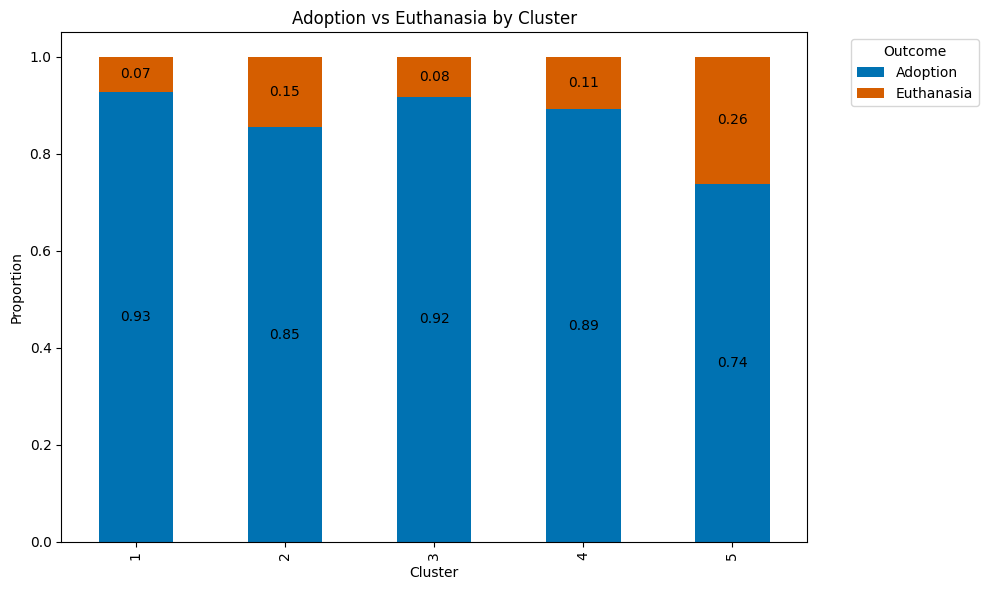

In [252]:
cluster_ae = pd.crosstab(
    df_ae["cluster_ordered"],
    df_ae["Outcome Type"],
    normalize="index"
)

# Colorblind-friendly palette (Okabe-Ito)
colors = ["#0072B2","#D55E00"]

ax = cluster_ae[["Adoption","Euthanasia"]].plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center")

plt.title("Adoption vs Euthanasia by Cluster")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.savefig(
    f"Charts/cluster_bar_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/tb/ynywfxxd6dncwv7hgqyf4b0m0000gn/T/ipykernel_24506/3649937627.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


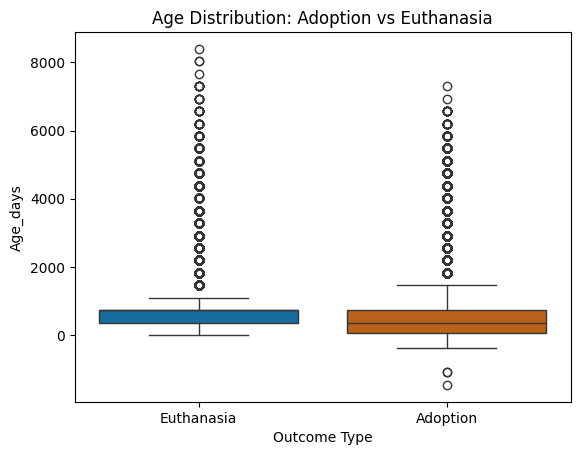

In [253]:
sns.boxplot(
    data=df_ae,
    x="Outcome Type",
    y="Age_days",
    palette=["#0072B2", "#D55E00"]
)

plt.title("Age Distribution: Adoption vs Euthanasia")
plt.show()

In [254]:
cluster_ae["Euthanasia"].sort_values(ascending=False)

cluster_ordered
5    0.262908
2    0.145733
4    0.108715
3    0.083264
1    0.072368
Name: Euthanasia, dtype: float64

/var/folders/tb/ynywfxxd6dncwv7hgqyf4b0m0000gn/T/ipykernel_24506/4226883991.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


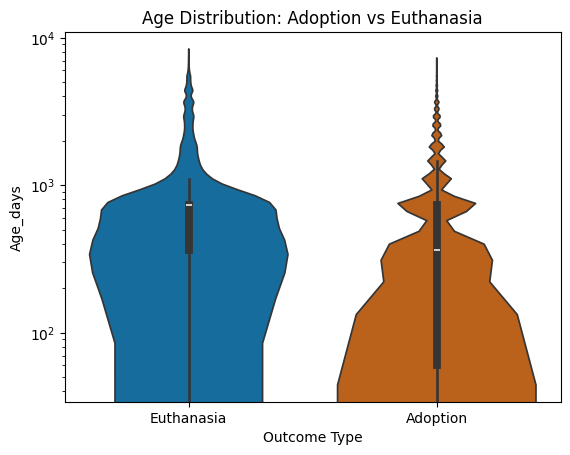

In [255]:
sns.violinplot(
    data=df_ae,
    x="Outcome Type",
    y="Age_days",
    palette=["#0072B2", "#D55E00"],
    cut=0
)
plt.yscale("log")
plt.title("Age Distribution: Adoption vs Euthanasia")

plt.savefig(
    f"Charts/cluster_violin_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

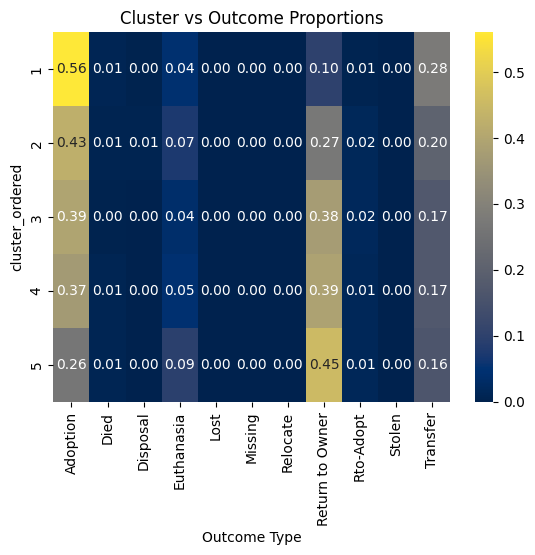

In [256]:
sns.heatmap(
    cluster_outcomes,
    annot=True,
    cmap="cividis",  # VERY good for colorblindness
    fmt=".2f"
)

plt.title("Cluster vs Outcome Proportions")
plt.show()

In [257]:
cluster_labels = {
    0: "Young Cats",
    1: "Older Dogs",
    2: "Mixed Breed Adults",
}

df_clustered["cluster_label"] = df_clustered["cluster"].map(cluster_labels)

In [258]:
# ##### Old, don't use 
# outcomes["DateTime"] = pd.to_datetime(outcomes["DateTime"], errors="coerce")

# adopted = outcomes[outcomes["Outcome Type"] == "Adoption"].copy()
# euthanized = outcomes[outcomes["Outcome Type"] == "Euthanasia"].copy()

# adopted["label"] = "Adopted"
# euthanized["label"] = "Euthanized"

# df_ml = pd.concat([adopted, euthanized])

In [259]:
# features = df_ml[[
#     "Animal Type",
#     "Sex upon Outcome",
#     "Age upon Outcome",
#     "Breed",
#     "Color"
# ]]

# labels = df_ml["label"]

In [260]:
# def convert_age(age):
#     if pd.isnull(age):
#         return None
#     num = int(re.findall(r"\d+", age)[0])
#     if "month" in age:
#         return num / 12
#     return num

# df_ml["AgeYears"] = df_ml["Age upon Outcome"].apply(convert_age)

In [261]:
# features = df_ml[[
#     "Animal Type",
#     "Sex upon Outcome",
#     "Breed",
#     "Color",
#     "AgeYears"
# ]]

In [262]:
# categorical_cols = ["Animal Type", "Sex upon Outcome", "Breed", "Color"]
# numeric_cols = ["AgeYears"]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
#         ("num", "passthrough", numeric_cols)
#     ]
# )

In [263]:
# features = features.copy()

# features = features.fillna({
#     "Animal Type": "Unknown",
#     "Sex upon Outcome": "Unknown",
#     "Breed": "Unknown",
#     "Color": "Unknown",
#     "AgeYears": features["AgeYears"].median()
# })

In [264]:
# kmeans = KMeans(n_clusters=3, random_state=42)

# pipeline = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("cluster", kmeans)
# ])

# clusters = pipeline.fit_predict(features)

# df_ml["Cluster"] = clusters

In [265]:
# print(pd.crosstab(df_ml["Cluster"], df_ml["label"], normalize="index"))

In [266]:
# X = pipeline.named_steps["preprocessor"].transform(features)

# umap = UMAP(n_components=42)
# components = umap.fit_transform(X)
# plt.figure(figsize=(8,6))
# centroids = np.array([components[df_ml["Cluster"] == i].mean(axis=0) for i in range(3)])

# plt.scatter(
#     components[:,0],
#     components[:,1],
#     c=df_ml["Cluster"],
#     cmap="viridis",
#     alpha=0.5
#     # centroids[:,0],
#     # centroids[:,1],
#     # c="red",
#     # s=200,
#     # marker="X"
# )

# for i in range(3):
#     plt.text(
#         centroids[i,0],
#         centroids[i,1],
#         f"Cluster {i}",
#         fontsize=12
#     )

# plt.title("Animal Clusters (PCA Projection)")
# plt.xlabel("PC1")
# plt.ylabel("PC2")

# plt.savefig(
#     f"Charts/cluster1.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

In [267]:
# pd.crosstab(df_ml["Cluster"], df_ml["label"], normalize="index")

In [268]:
# for col in ["Animal Type", "Sex upon Outcome", "Breed", "Color"]:
#     print("\n", col)
#     print(df_ml.groupby("Cluster")[col].value_counts(normalize=True).unstack())

In [269]:
# df_ml.groupby("Cluster")["AgeYears"].describe()

In [270]:
# cluster_summary = pd.crosstab(
#     df_ml["Cluster"],
#     df_ml["Animal Type"],
#     normalize="index"
# )

# sns.heatmap(cluster_summary, annot=True, cmap="Blues")
# plt.title("Cluster Composition by Animal Type")